<a href="https://colab.research.google.com/github/TiaGolyan2508/Minor-Project/blob/main/brainTumorSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries for medical image processing
# nibabel -> used to read MRI files (.nii/.nii.gz)
# monai -> medical imaging deep learning toolkit
# grad-cam -> for explainable AI visualization
!pip install nibabel
!pip install monai
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import important libraries

import torch                     # PyTorch deep learning framework
import torch.nn as nn            # neural network layers
import numpy as np               # numerical operations
import nibabel as nib            # to load MRI files
import matplotlib.pyplot as plt  # visualization
from torch.utils.data import Dataset, DataLoader

In [4]:
!ls /content/drive/MyDrive/

 1696492550414.jpg
'Certificate for Tiya golyan for "Ryan College For Higher Edu...".pdf'
 Classroom
'Colab Notebooks'
 College-Authorization-letter-SIH2025.docx
 Final_Project_Report_software.pdf
'Getting started.pdf'
 IMG-20230618-WA0002.jpg
 IMG-20250202-WA0016.jpg
 IMG-20250218-WA0042.jpg
'IMG_20250325_214149 (1).jpg'
 IMG_20250325_214149.jpg
 IMG_20250731_000145.jpg
 IMG_20250731_000320.jpg
 IMG_20250731_000537.jpg
'Kaagaz_20241127_225314298136 (1).pdf'
 Nexora_SIH25070.pdf
'Project AI use Survey_tia golyan_500122580.pdf'
'resume_tia golyan (1).pdf'
'resume_tia golyan.pdf'
 SAMARTH_500122580
 Screenshot_2024-07-22-01-37-07-010_com.linkedin.android.jpg
 Screenshot_2024-12-07-12-37-20-437_com.android.chrome.jpg
 SRS_CASE_STUDY.docx
'Teaching feedback form.gform'
'Teaching feedback form (Responses) (1).xlsx'
'Teaching feedback form (Responses).gsheet'
'Teaching feedback form (Responses).xlsx'
'The Smiling Depression.gdoc'
 tia_golyan_2025-1-1.pdf
'tia_golyan_2025 (1).pdf'
'tia_golyan

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/

 BraTS	'Colab Notebooks'  'Memories '


In [ ]:
!ls /content/drive/MyDrive/BraTS/

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tiya2508","key":"6f413a343154b5994bc4a0da920d3d28"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.16G/4.16G [00:42<00:00, 290MB/s]
100% 4.16G/4.16G [00:42<00:00, 105MB/s]


In [9]:
!unzip brats20-dataset-training-validation.zip -d /content/brats

Archive:  brats20-dataset-training-validation.zip
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_seg.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t2.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_flair.nii  
  inflating: /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_seg.nii  
  inflating: /co

In [10]:
!ls /content/brats

BraTS2020_TrainingData	BraTS2020_ValidationData


In [11]:
!ls /content/brats/BraTS2020_TrainingData

MICCAI_BraTS2020_TrainingData


In [12]:
!ls /content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData

BraTS20_Training_001  BraTS20_Training_125  BraTS20_Training_249
BraTS20_Training_002  BraTS20_Training_126  BraTS20_Training_250
BraTS20_Training_003  BraTS20_Training_127  BraTS20_Training_251
BraTS20_Training_004  BraTS20_Training_128  BraTS20_Training_252
BraTS20_Training_005  BraTS20_Training_129  BraTS20_Training_253
BraTS20_Training_006  BraTS20_Training_130  BraTS20_Training_254
BraTS20_Training_007  BraTS20_Training_131  BraTS20_Training_255
BraTS20_Training_008  BraTS20_Training_132  BraTS20_Training_256
BraTS20_Training_009  BraTS20_Training_133  BraTS20_Training_257
BraTS20_Training_010  BraTS20_Training_134  BraTS20_Training_258
BraTS20_Training_011  BraTS20_Training_135  BraTS20_Training_259
BraTS20_Training_012  BraTS20_Training_136  BraTS20_Training_260
BraTS20_Training_013  BraTS20_Training_137  BraTS20_Training_261
BraTS20_Training_014  BraTS20_Training_138  BraTS20_Training_262
BraTS20_Training_015  BraTS20_Training_139  BraTS20_Training_263
BraTS20_Training_016  Bra

In [13]:
data_dir = "/content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

In [14]:
import os

patients = [os.path.join(data_dir, p) for p in os.listdir(data_dir)]

print("Total patients:", len(patients))

Total patients: 371


In [15]:
patients = patients[:20]

In [16]:
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np
import os

class BraTSDataset(Dataset):

    """
    Custom PyTorch Dataset for BraTS MRI data.

    Each patient folder contains:
    T1, T2, T1ce, FLAIR MRI modalities + tumor segmentation mask.

    We convert 3D MRI volumes into multiple 2D slices for training.
    """

    def __init__(self, patient_dirs):

        self.samples = []

        # Loop through each patient folder
        for patient in patient_dirs:

            patient_id = os.path.basename(patient)

            # Construct file paths for all modalities
            t1_path = os.path.join(patient, patient_id + "_t1.nii")
            t2_path = os.path.join(patient, patient_id + "_t2.nii")
            t1ce_path = os.path.join(patient, patient_id + "_t1ce.nii")
            flair_path = os.path.join(patient, patient_id + "_flair.nii")
            seg_path = os.path.join(patient, patient_id + "_seg.nii")

            # Load MRI volumes
            t1 = nib.load(t1_path).get_fdata()
            t2 = nib.load(t2_path).get_fdata()
            t1ce = nib.load(t1ce_path).get_fdata()
            flair = nib.load(flair_path).get_fdata()
            seg = nib.load(seg_path).get_fdata()

            # Convert 3D volume into 2D slices
            for i in range(t1.shape[2]):

                image = np.stack([
                    t1[:, :, i],
                    t2[:, :, i],
                    t1ce[:, :, i],
                    flair[:, :, i]
                ], axis=0)

                mask = seg[:, :, i]

                self.samples.append((image, mask))

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        image, mask = self.samples[idx]

        image = torch.tensor(image).float()
        mask = torch.tensor(mask).float().unsqueeze(0)

        return image, mask

In [17]:
dataset = BraTSDataset(patients)

print("Total training slices:", len(dataset))

Total training slices: 3100


In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("DataLoader ready")

DataLoader ready


In [19]:
# Use only first 10 patients for faster demo training
patients = patients[:10]

print("Using patients:", len(patients))

Using patients: 10


In [20]:
# Create dataset object
dataset = BraTSDataset(patients)

print("Total slices available:", len(dataset))

Total slices available: 1550


In [21]:
from torch.utils.data import DataLoader

# DataLoader loads images in batches during training
train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("DataLoader ready")

DataLoader ready


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- Novelty Module: Dynamic Modality Reliability ----
class ModalityReliability(nn.Module):
    """
    Learns which MRI modality (T1, T2, T1ce, FLAIR) is most useful
    and weights them dynamically.
    """
    def __init__(self, channels=4):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        weights = self.sigmoid(self.conv(x))
        return x * weights


# ---- Basic U-Net Convolution Block ----
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ---- Attention Gate (focus on tumor regions) ----
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.psi(F.relu(g1 + x1))
        return x * psi


# ---- Full Segmentation Model ----
class BrainTumorSegmentationModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Novelty block
        self.modality_attention = ModalityReliability()

        # Encoder
        self.conv1 = DoubleConv(4, 64)
        self.pool = nn.MaxPool2d(2)

        self.conv2 = DoubleConv(64,128)

        # Decoder
        self.up = nn.ConvTranspose2d(128,64,2,stride=2)

        self.att = AttentionBlock(64,64,32)

        self.conv3 = DoubleConv(128,64)

        # Output segmentation mask
        self.out = nn.Conv2d(64,1,1)

    def forward(self, x):

        # Modality weighting
        x = self.modality_attention(x)

        # Encoder
        e1 = self.conv1(x)
        e2 = self.conv2(self.pool(e1))

        # Decoder
        d1 = self.up(e2)

        # Attention skip connection
        e1_att = self.att(d1,e1)

        d1 = torch.cat([d1,e1_att],dim=1)

        d1 = self.conv3(d1)

        return torch.sigmoid(self.out(d1))

In [23]:
def dice_loss(pred, target):

    smooth = 1

    intersection = (pred * target).sum()

    return 1 - ((2 * intersection + smooth) /
               (pred.sum() + target.sum() + smooth))

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = BrainTumorSegmentationModel().to(device)

Using device: cuda


In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [26]:
epochs = 40

for epoch in range(epochs):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))

Epoch: 1 Loss: 0.882663803002269
Epoch: 2 Loss: 0.8089530503319711
Epoch: 3 Loss: 0.7065467332134542
Epoch: 4 Loss: 0.5890840520871055
Epoch: 5 Loss: 0.4506258397679968
Epoch: 6 Loss: 0.37444747262394307
Epoch: 7 Loss: 0.35799694199537496
Epoch: 8 Loss: 0.3071781315447129
Epoch: 9 Loss: 0.290940516081053
Epoch: 10 Loss: 0.29454340947043034
Epoch: 11 Loss: 0.24582120361401863
Epoch: 12 Loss: 0.2418889547746206
Epoch: 13 Loss: 0.23115060793370315
Epoch: 14 Loss: 0.22672921265523457
Epoch: 15 Loss: 0.2352162412146932
Epoch: 16 Loss: 0.20101701045773693
Epoch: 17 Loss: 0.23548805682929522
Epoch: 18 Loss: 0.2219392158014258
Epoch: 19 Loss: 0.1937904231941577
Epoch: 20 Loss: 0.2003489345619359
Epoch: 21 Loss: 0.16721923080916257
Epoch: 22 Loss: 0.19398576082642546
Epoch: 23 Loss: 0.18053468769973086
Epoch: 24 Loss: 0.195526264377476
Epoch: 25 Loss: 0.1542018925406269
Epoch: 26 Loss: 0.1651943201564022
Epoch: 27 Loss: 0.15463935207460344
Epoch: 28 Loss: 0.1280897333449924
Epoch: 29 Loss: 0.20

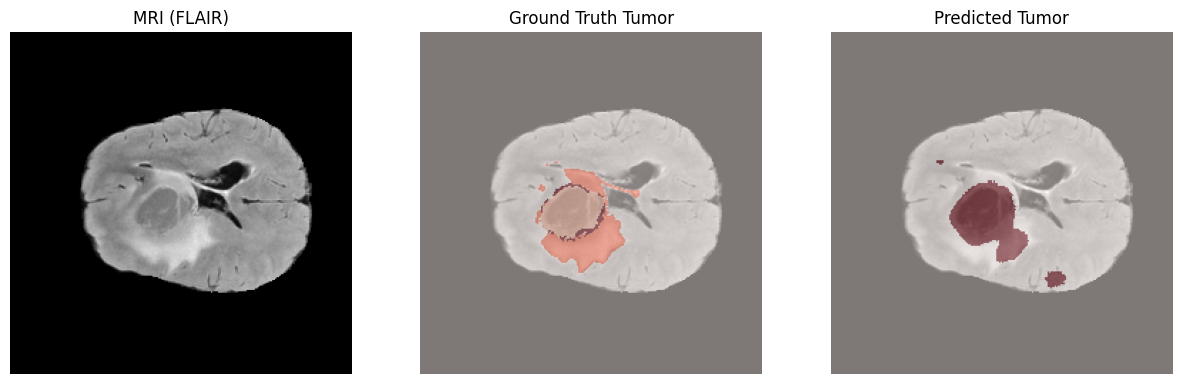

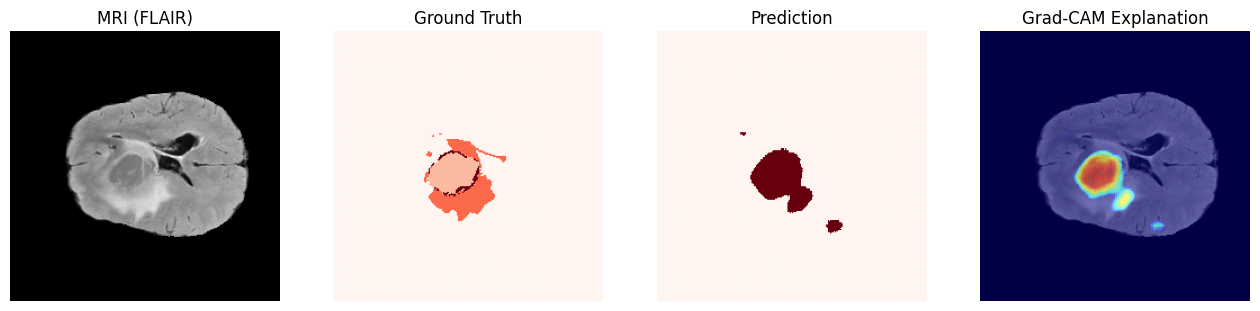

In [50]:
# =====================================
# Get ONE batch and reuse everywhere
# =====================================

images, masks = next(iter(train_loader))

images = images.to(device)

# Model prediction
with torch.no_grad():
    preds = model(images)

# Move tensors to CPU
images_cpu = images.cpu()
masks_cpu = masks.cpu()
preds_cpu = preds.cpu()

# Convert prediction to binary mask
preds_cpu = (preds_cpu > 0.5).float()

# -------------------------------------
# Find slice with tumor
# -------------------------------------

slice_index = None
for i in range(masks_cpu.shape[0]):
    if masks_cpu[i].sum() > 0:
        slice_index = i
        break

if slice_index is None:
    slice_index = 0

# Extract SAME slice for everything
mri = images_cpu[slice_index][3].numpy()  # FLAIR
gt = masks_cpu[slice_index][0].numpy()
pred = preds_cpu[slice_index][0].numpy()

# =====================================
# Segmentation Visualization
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI (FLAIR)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mri, cmap="gray")
plt.imshow(gt, cmap="Reds", alpha=0.5)
plt.title("Ground Truth Tumor")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mri, cmap="gray")
plt.imshow(pred, cmap="Reds", alpha=0.5)
plt.title("Predicted Tumor")
plt.axis("off")

plt.show()

# =====================================
# Explainable AI (Grad-CAM)
# =====================================

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
import numpy as np

# Normalize MRI
mri_norm = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)

# Convert grayscale → RGB
mri_rgb = np.stack([mri_norm, mri_norm, mri_norm], axis=2)

# Create Grad-CAM target
pred_mask = pred > 0.5
targets = [SemanticSegmentationTarget(0, pred_mask)]

# Select layer
target_layers = [model.conv3.conv[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

# Run Grad-CAM on SAME batch
grayscale_cam = cam(input_tensor=images, targets=targets)

cam_map = grayscale_cam[slice_index]

# Overlay heatmap
overlay = show_cam_on_image(mri_rgb, cam_map, use_rgb=True)

# =====================================
# Final Visualization
# =====================================

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI (FLAIR)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt, cmap="Reds")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred, cmap="Reds")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(overlay)
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.show()

In [37]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=43b2b5424c6ca532dad8720cf11196f0e031d52c2aa2c20d038173a77edb2d34
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [38]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget

In [52]:
#evaluation matrix
import numpy as np

def evaluate_metrics(pred, gt):

    pred = pred.flatten()
    gt = gt.flatten()

    TP = np.sum((pred == 1) & (gt == 1))
    FP = np.sum((pred == 1) & (gt == 0))
    FN = np.sum((pred == 0) & (gt == 1))
    TN = np.sum((pred == 0) & (gt == 0))

    dice = (2*TP) / (2*TP + FP + FN + 1e-8)

    iou = TP / (TP + FP + FN + 1e-8)

    precision = TP / (TP + FP + 1e-8)

    recall = TP / (TP + FN + 1e-8)

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)

    return dice, iou, precision, recall, accuracy
dice, iou, precision, recall, accuracy = evaluate_metrics(pred_mask, gt)

print("Dice Score:", dice)
print("IoU:", iou)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)

Dice Score: 0.9330612244859875
IoU: 0.8745218056551299
Precision: 0.8819444444376394
Recall: 0.9904679375997361
Accuracy: 0.9970631424374132


In [53]:
import torch.nn.functional as F

def dice_bce_loss(pred, target):

    smooth = 1

    intersection = (pred * target).sum()

    dice = 1 - ((2*intersection + smooth) /
               (pred.sum() + target.sum() + smooth))

    bce = F.binary_cross_entropy(pred, target)

    return dice + bce

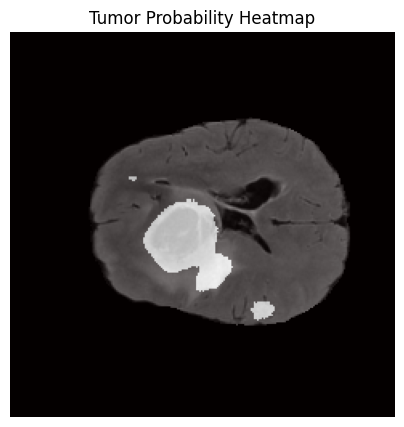

In [55]:
plt.figure(figsize=(5,5))

plt.imshow(mri, cmap="gray")

plt.imshow(pred, cmap="hot", alpha=0.5)

plt.title("Tumor Probability Heatmap")

plt.axis("off")

plt.show()